<a href="https://colab.research.google.com/github/Aaguilar123/Superstore-Sales-Forecast/blob/Attila-branch/shared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/drive/1SwrU7YJHVxUgQ6tgZhZFecHBtJqblUV_#scrollTo=D5d44J5bv_3q" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Retail Sales Forecasting and Demand Intelligence System**

## Definition of the Forecasting Problem & Goals

**1.** The objective of this project is to develop a robust retail sales forecasting system using historical transactional sales data from the Superstore Sales Forecasting dataset sourced from Kaggle (file: train.csv), originally published as the https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting/data . The dataset spans four years of retail activity and contains irregular transaction-level observations, which were transformed into structured time-series datasets to support formal forecasting analysis.

**2.** The forecasting task focuses on predicting Total Sales Revenue ($) across two operationally relevant forecasting horizons:

- Short-Term Forecasting:
**7-day** ahead daily sales prediction to support short-term inventory planning, staffing decisions, and operational scheduling.

- Medium-Term Forecasting:
**1-month** ahead monthly sales prediction to support strategic planning, budgeting, resource allocation, and demand management.

# Data Exploration, Preparation, and Feature Engineering for Retail Sales Forecasting

## Raw Data Exploration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")

df = pd.read_csv('https://raw.githubusercontent.com/renju-john/Superstore-Sales-Forecast/refs/heads/main/Superstore-Sales-Forecast%20/individual_models/Data/train.csv')

print("1. DATA AUDIT: MISSING VALUES")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.any() else "No missing values found.")
df = df.dropna(subset=['Postal Code'])

print("\n2. DATA AUDIT: TIME SPAN & FREQUENCY")
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
start_date = df['Order Date'].min()
end_date = df['Order Date'].max()
total_days = (end_date - start_date).days

print(f"Dataset Start Date : {start_date.date()}")
print(f"Dataset End Date   : {end_date.date()}")
print(f"Total Time Span    : {total_days} days (~4 years)")
print(f"Frequency          : Transactional (Irregular Daily)")

print("\n3. VARIABLE SUMMARY")
print(f"Total Transactions : {len(df)}")
print(f"Total Columns      : {len(df.columns)}")

1. DATA AUDIT: MISSING VALUES
Postal Code    11
dtype: int64

2. DATA AUDIT: TIME SPAN & FREQUENCY
Dataset Start Date : 2015-01-03
Dataset End Date   : 2018-12-30
Total Time Span    : 1457 days (~4 years)
Frequency          : Transactional (Irregular Daily)

3. VARIABLE SUMMARY
Total Transactions : 9789
Total Columns      : 18


## Data Preprocessing and Feature Transformation

In [7]:
# (Treating missing dates as zero sales - Real retail info)
df_daily = df.set_index('Order Date')['Sales'].resample('D').sum().fillna(0).reset_index()
df_daily.columns = ['date', 'sales']
df_daily['day_of_week'] = df_daily['date'].dt.day_name()

df_daily['date'] = pd.to_datetime(df_daily['date']).dt.date

# Monthly Aggregation
df_monthly = df.set_index('Order Date')['Sales'].resample('MS').sum().reset_index()
df_monthly.columns = ['date', 'sales']
df_monthly['Month'] = pd.to_datetime(df_monthly['date']).dt.month
df_monthly['rolling_mean_3'] = df_monthly['sales'].rolling(3).mean()
df_monthly['date'] = pd.to_datetime(df_monthly['date']).dt.date

print("\n - TRANSFORMATIONS")
df_daily['sales_log'] = np.log1p(df_daily['sales'])
df_monthly['sales_log'] = np.log1p(df_monthly['sales'])

# Save Cleaned Datasets
df_daily.to_csv('https://raw.githubusercontent.com/renju-john/Superstore-Sales-Forecast/refs/heads/main/Superstore-Sales-Forecast%20/individual_models/Data/clean_daily_ready.csv', index=False)
df_monthly.to_csv('https://raw.githubusercontent.com/renju-john/Superstore-Sales-Forecast/refs/heads/main/Superstore-Sales-Forecast%20/individual_models/Data/clean_monthly_ready.csv', index=False)
print("Cleaned and log-transformed datasets exported: 'clean_daily_ready.csv' & 'clean_monthly_ready.csv'")

df_daily.head()
df_monthly.head()


 - TRANSFORMATIONS
Cleaned and log-transformed datasets exported: 'clean_daily_ready.csv' & 'clean_monthly_ready.csv'


,date,sales,Month,rolling_mean_3,sales_log
0,2015-01-01,14205.707,1,NaN,9.561469
1,2015-02-01,4519.892,2,NaN,8.416465
2,2015-03-01,55205.797,3,24643.798667,10.918841
3,2015-04-01,27906.855,4,29210.848000,10.236663
4,2015-05-01,23644.303,5,35585.651667,10.070920


Preprocessing summary:
Sales data were resampled into daily and monthly series, missing dates were treated as zero-sales periods, and log transformation was applied to reduce skewness and improve forecasting model stability.

## Explanatory Data Analysis

### Distribution analysis:

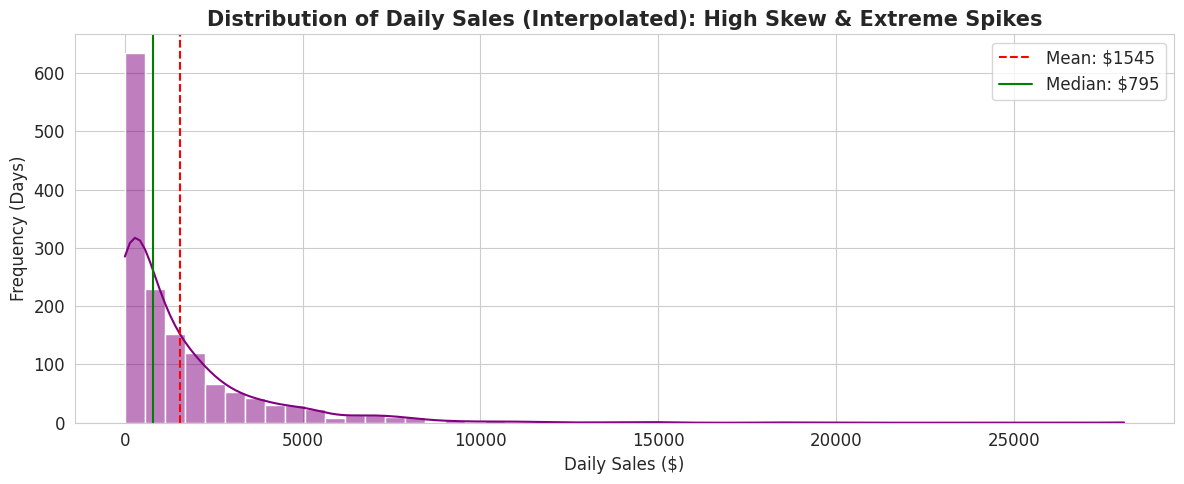

In [8]:
plt.figure(figsize=(12, 5))
sns.histplot(df_daily['sales'], bins=50, kde=True, color='purple')
plt.title('Distribution of Daily Sales (Interpolated): High Skew & Extreme Spikes', fontsize=15, fontweight='bold')
plt.xlabel('Daily Sales ($)')
plt.ylabel('Frequency (Days)')
plt.axvline(df_daily['sales'].mean(), color='red', linestyle='--', label=f"Mean: ${df_daily['sales'].mean():.0f}")
plt.axvline(df_daily['sales'].median(), color='green', linestyle='-', label=f"Median: ${df_daily['sales'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()


The daily sales distribution is strongly right-skewed, with the mean notably exceeding the median, indicating extreme positive outliers. This justified the use of the log transformation (log1p) as a variance-stabilising step to reduce skewness and improve forecasting model performance.

### Time-series behaviour across forecasting horizons

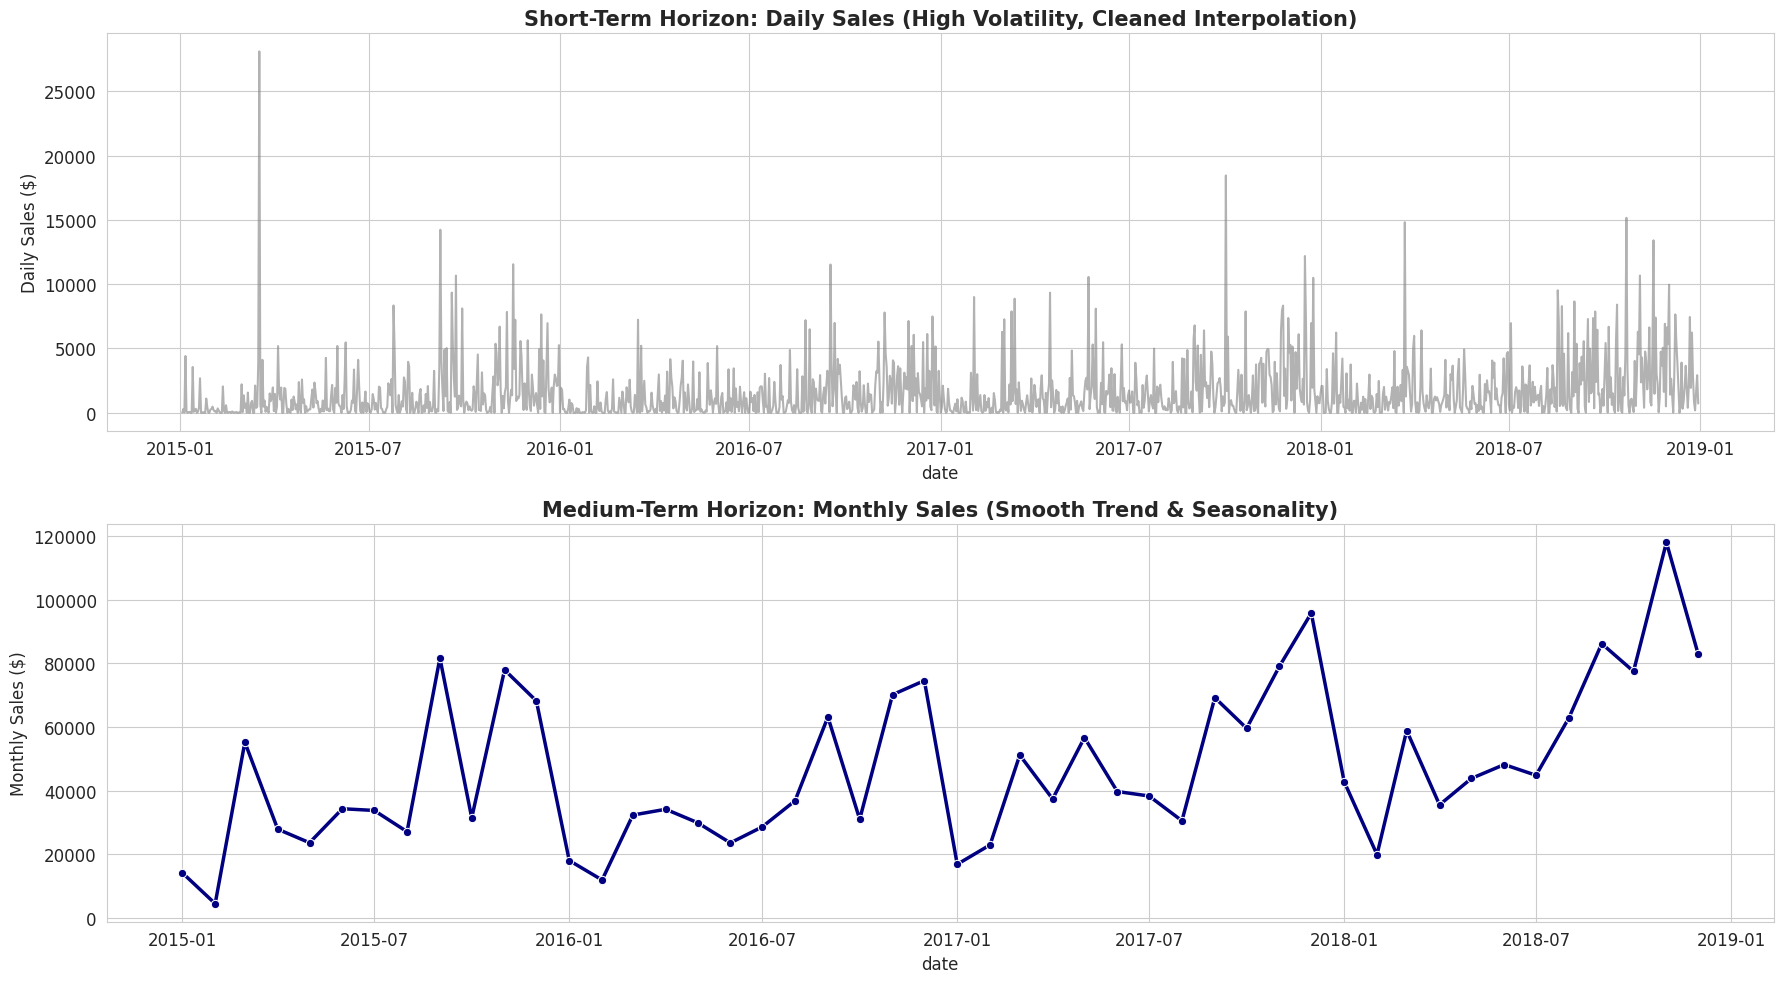

In [9]:
fig1 = plt.figure(figsize=(18, 10))
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
sns.lineplot(data=df_daily, x=pd.to_datetime(df_daily['date']), y='sales', color='gray', alpha=0.6, ax=ax1)
ax1.set_title('Short-Term Horizon: Daily Sales (High Volatility, Cleaned Interpolation)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Daily Sales ($)')

ax2 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
sns.lineplot(data=df_monthly, x=pd.to_datetime(df_monthly['date']), y='sales', marker='o', linewidth=2.5, color='navy', ax=ax2)
ax2.set_title('Medium-Term Horizon: Monthly Sales (Smooth Trend & Seasonality)', fontsize=15, fontweight='bold')
ax2.set_ylabel('Monthly Sales ($)')
plt.tight_layout()
plt.show()


### Seasonality Analysis

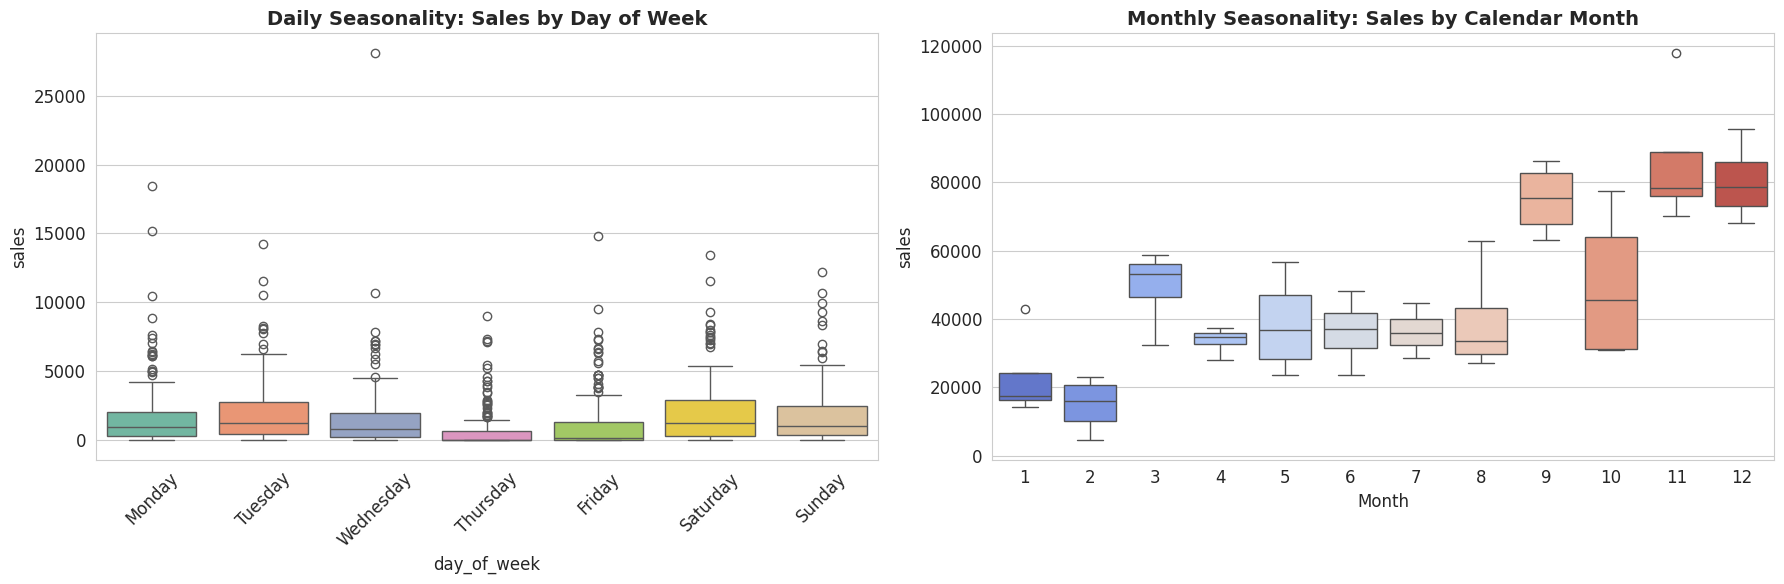

In [10]:
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=df_daily, x='day_of_week', y='sales', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], ax=ax3, palette='Set2')
ax3.set_title('Daily Seasonality: Sales by Day of Week', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

sns.boxplot(data=df_monthly, x='Month', y='sales', ax=ax4, palette='coolwarm')
ax4.set_title('Monthly Seasonality: Sales by Calendar Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Autocorrelation Analysis

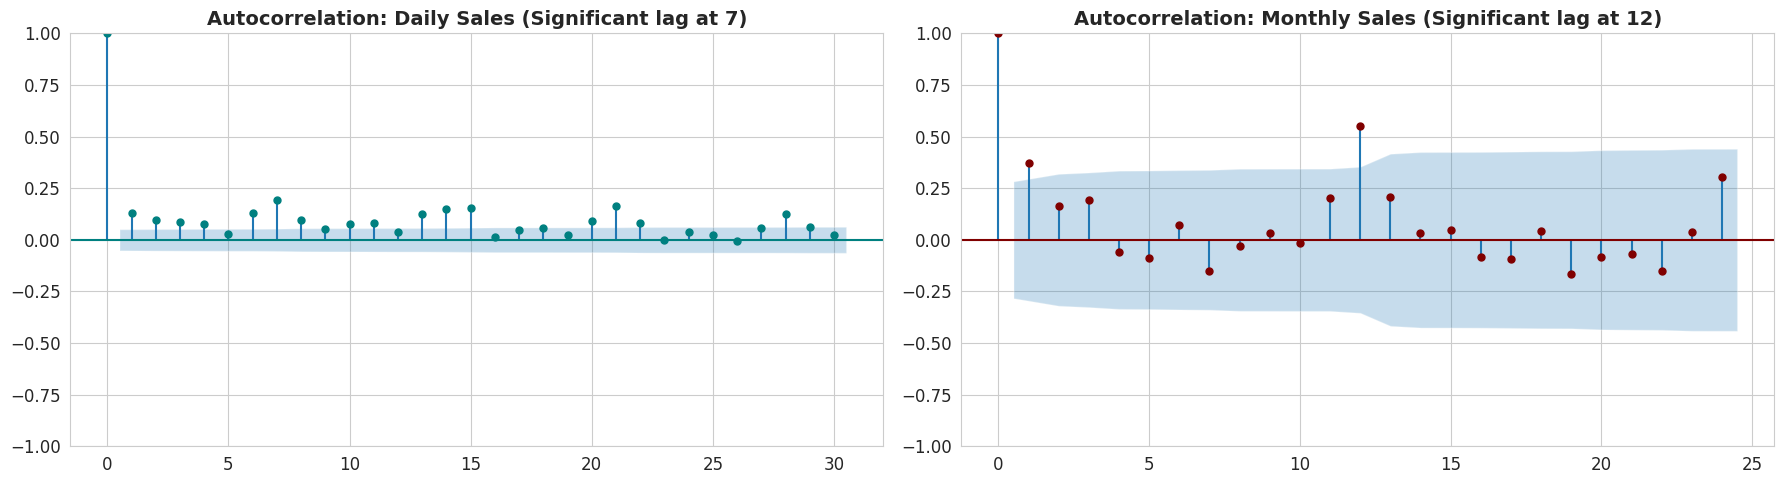

In [11]:
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(df_daily['sales'], lags=30, ax=ax5, color='teal')
ax5.set_title('Autocorrelation: Daily Sales (Significant lag at 7)', fontsize=14, fontweight='bold')

plot_acf(df_monthly['sales'].dropna(), lags=24, ax=ax6, color='maroon')
ax6.set_title('Autocorrelation: Monthly Sales (Significant lag at 12)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Long-Term Sales Trend Visualization

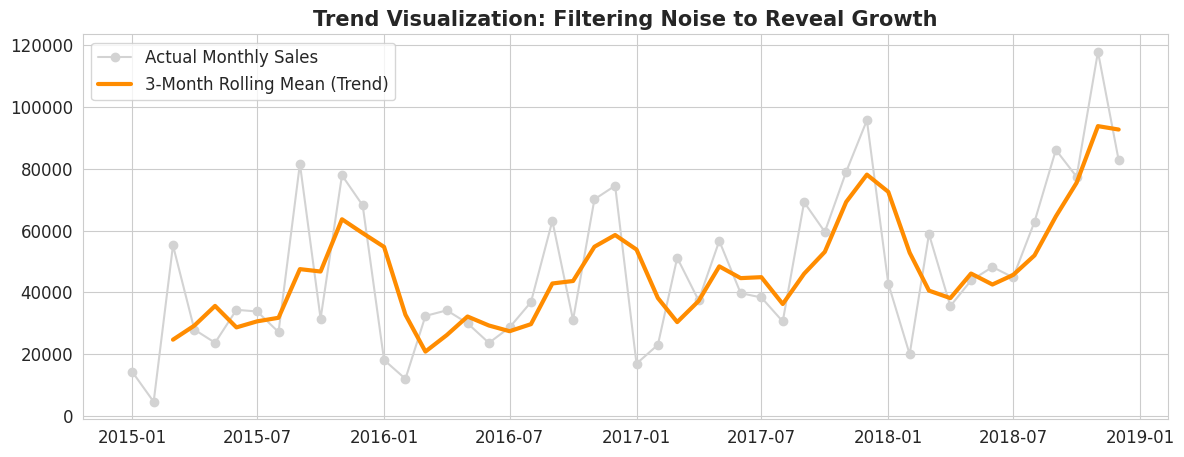

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(df_monthly['date']), df_monthly['sales'], label='Actual Monthly Sales', color='lightgray', marker='o')
plt.plot(pd.to_datetime(df_monthly['date']), df_monthly['rolling_mean_3'], label='3-Month Rolling Mean (Trend)', color='darkorange', linewidth=3)
plt.title('Trend Visualization: Filtering Noise to Reveal Growth', fontsize=15, fontweight='bold')
plt.legend()
plt.show()


### Forecasting Problem Definition

In [13]:
# ==========================================
# 9. FORECASTING PROBLEM DEFINITION
# ==========================================


### Weekly Seasonality Analysis
The boxplots reveal the variance and median sales across different days of the week, highlighting distinct weekly purchasing patterns that non-linear models like XGBoost can exploit.

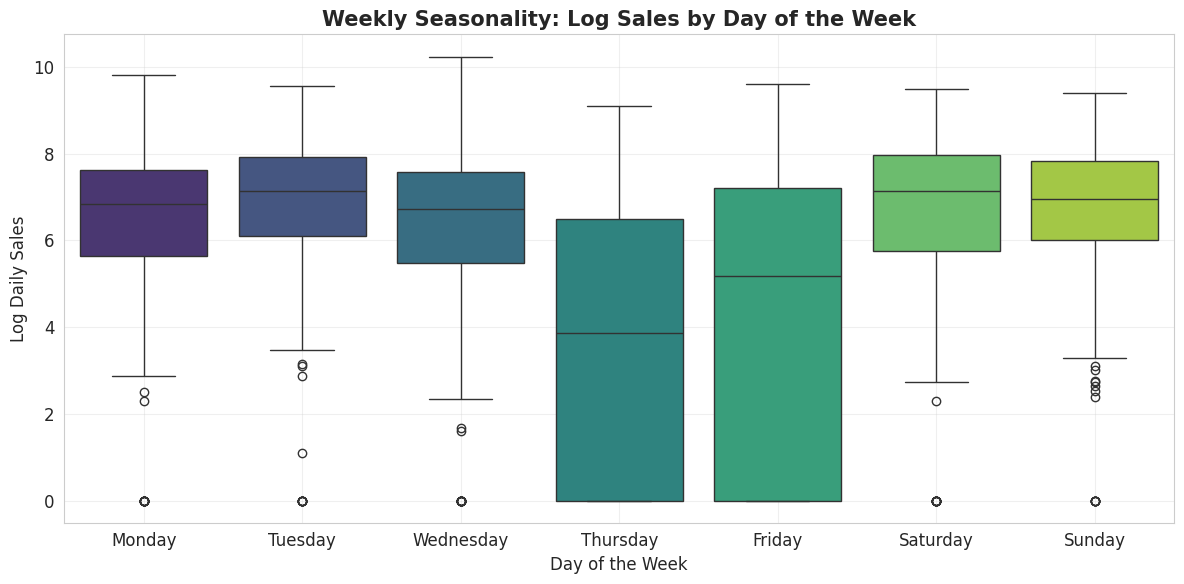

In [14]:
plt.figure(figsize=(12, 6))
# Order the days of the week logically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_daily, x='day_of_week', y='sales_log', order=day_order, palette='viridis')
plt.title('Weekly Seasonality: Log Sales by Day of the Week', fontsize=15, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Log Daily Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Monthly Seasonality Analysis
This highlights structural annual trends, such as end-of-year holiday spikes (Q4), which dictates the necessity of capturing 12-month seasonality in our forecasting algorithms.

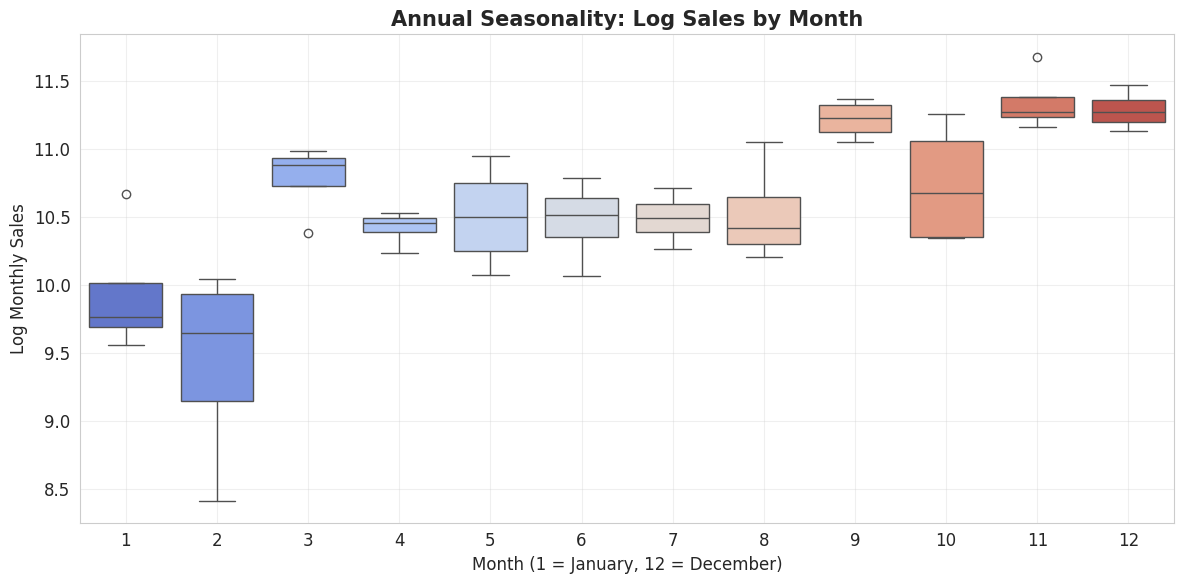

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_monthly, x='Month', y='sales_log', palette='coolwarm')
plt.title('Annual Seasonality: Log Sales by Month', fontsize=15, fontweight='bold')
plt.xlabel('Month (1 = January, 12 = December)')
plt.ylabel('Log Monthly Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Autocorrelation (ACF) Plot
The ACF plot mathematically confirms the presence of short-term memory and weekly autocorrelation (noticeable spikes every 7 days). This directly informed our decision to construct `lag_1` and `lag_7` features for the machine learning pipelines.

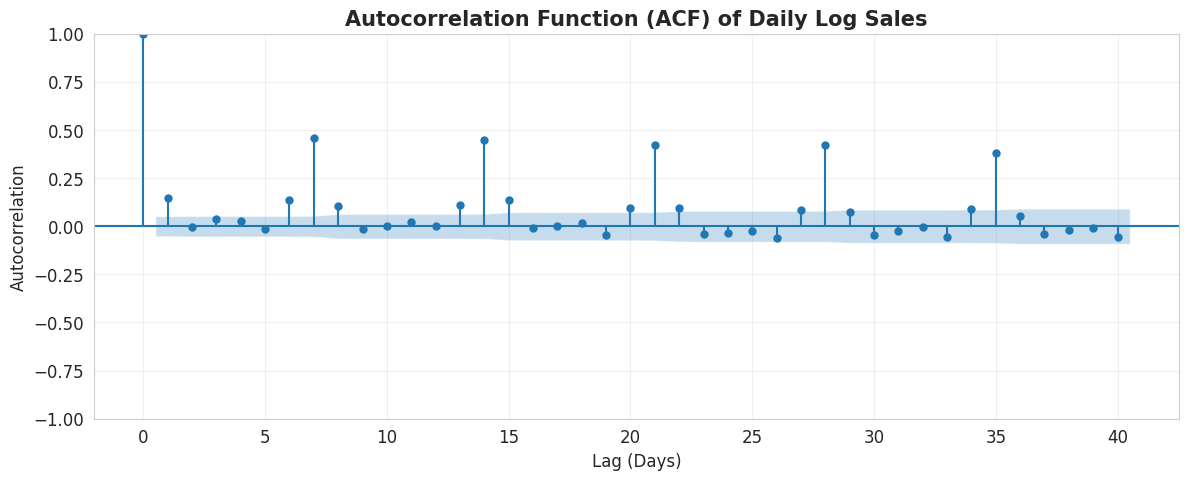

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(df_daily['sales_log'], lags=40, ax=ax, alpha=0.05)
plt.title('Autocorrelation Function (ACF) of Daily Log Sales', fontsize=15, fontweight='bold')
plt.xlabel('Lag (Days)')
plt.ylabel('Autocorrelation')
plt.grid(True, alpha=0.3)
plt.show()